# SMS Spam Detection

### NLP-классификация мошеннических сообщений


**Цель:** разработка модели классификации текстов для автоматического выявления спам- и фишинговых SMS-сообщений.  
**Датасет:** [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) — 5 572 сообщений (UCI ML Repository)  
**Стек:** Python · Pandas · scikit-learn · NLTK · Matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

nltk.download('stopwords')

sns.set_theme(style="whitegrid")
print("All imports OK")

All imports OK


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 1. Загрузка данных

In [4]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
df.head(10)

Dataset shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## 2. Разведочный анализ данных (EDA)

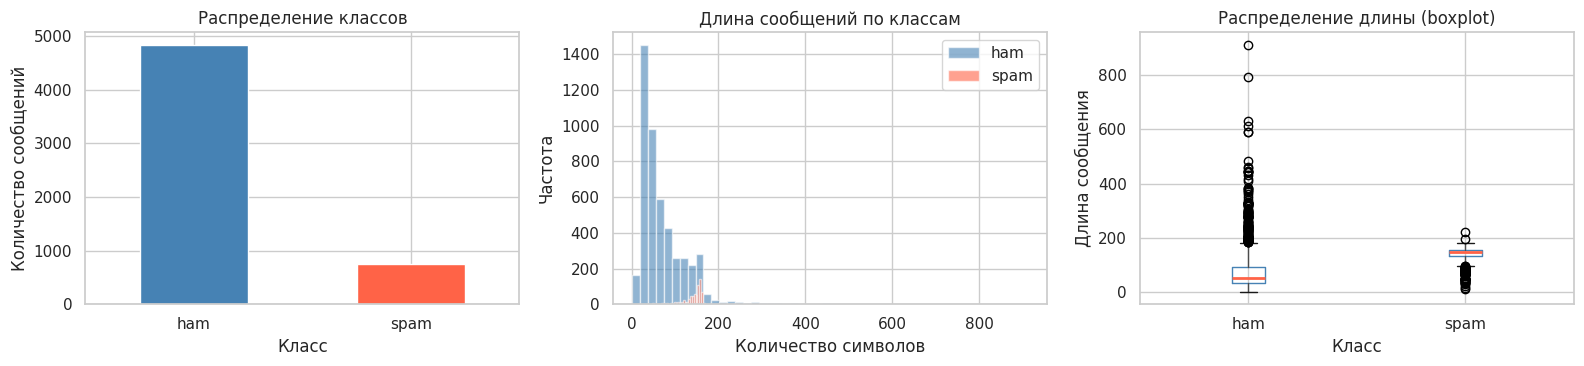

        count   mean   std   min    25%    50%    75%    max
label                                                       
ham    4825.0   71.5  58.4   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.7  28.9  13.0  133.0  149.0  157.0  223.0


In [5]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

df['msg_length'] = df['message'].apply(len)

# распределение классов
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_title('Распределение классов')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество сообщений')
axes[0].set_xticklabels(['ham', 'spam'], rotation=0)

# длина сообщений по классам
for label, color in zip(['ham', 'spam'], ['steelblue', 'tomato']):
    subset = df[df['label'] == label]['msg_length']
    axes[1].hist(subset, bins=50, alpha=0.6, label=label, color=color)
axes[1].set_title('Длина сообщений по классам')
axes[1].set_xlabel('Количество символов')
axes[1].set_ylabel('Частота')
axes[1].legend()

# boxplot длины
df.boxplot(column='msg_length', by='label', ax=axes[2],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
axes[2].set_title('Распределение длины (boxplot)')
axes[2].set_xlabel('Класс')
axes[2].set_ylabel('Длина сообщения')
plt.suptitle('')

plt.tight_layout()
plt.show()

# статистика
print(df.groupby('label')['msg_length'].describe().round(1))

## 3. Предобработка текста

In [6]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess)

# проверка
print("Оригинал:")
print(df.loc[2, 'message'])
print("\nПосле обработки:")
print(df.loc[2, 'clean_message'])

Оригинал:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

После обработки:
free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over


## 4. Топ-слова по классам

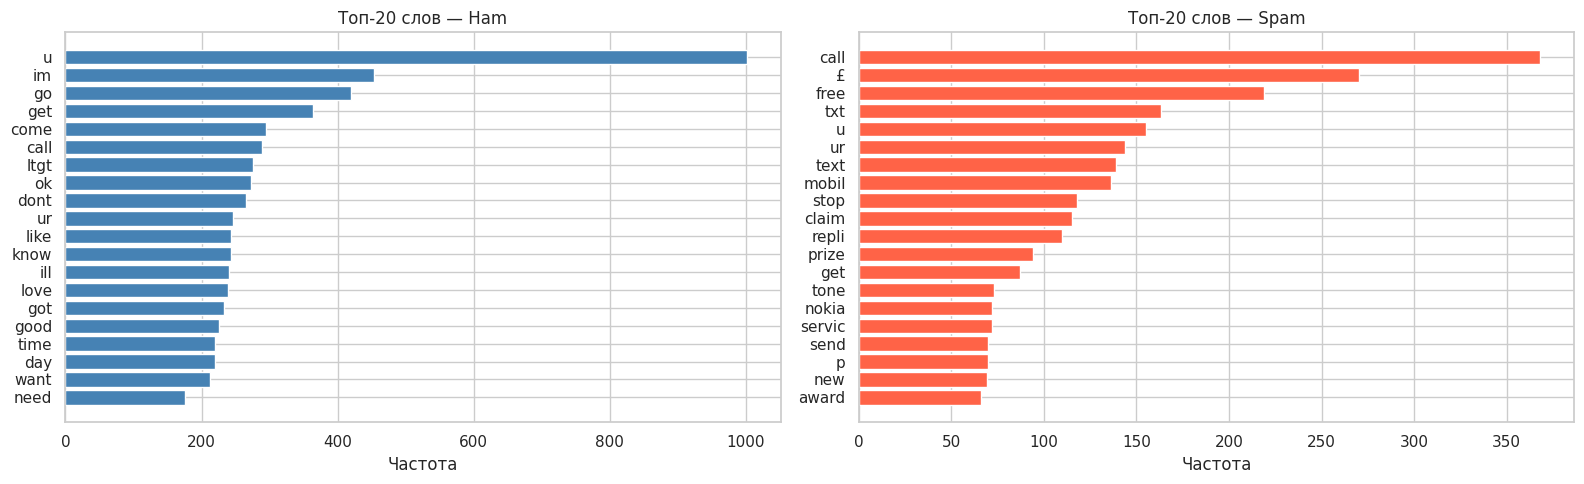

In [7]:
from collections import Counter

def get_top_words(label, n=20):
    texts = df[df['label'] == label]['clean_message']
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

ham_words = get_top_words('ham')
spam_words = get_top_words('spam')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, words, title, color in zip(
    axes,
    [ham_words, spam_words],
    ['Топ-20 слов — Ham', 'Топ-20 слов — Spam'],
    ['steelblue', 'tomato']
):
    words_df = pd.DataFrame(words, columns=['word', 'count'])
    ax.barh(words_df['word'][::-1], words_df['count'][::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('Частота')

plt.tight_layout()
plt.show()

## 5. Моделирование

Обучаем два классических подхода для классификации текста:
- **Naive Bayes** — классический базовый алгоритм для спам-фильтров
- **Logistic Regression** — более гибкая модель, часто показывает лучший результат на TF-IDF признаках

Поскольку датасет несбалансирован (87% ham / 13% spam), в качестве основных метрик используем **Precision, Recall и F1** для класса spam, а не accuracy.

In [8]:
# разбивка на train/test
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_message'], df['label_num'],
    test_size=0.2, random_state=42, stratify=df['label_num']
)

# TF-IDF векторизация
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# обучение моделей
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

print("Модели обучены")
print(f"Train size: {X_train_tfidf.shape[0]} | Test size: {X_test_tfidf.shape[0]}")

Модели обучены
Train size: 4457 | Test size: 1115


### 5.1 Оценка качества моделей


  Naive Bayes
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


  Logistic Regression
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



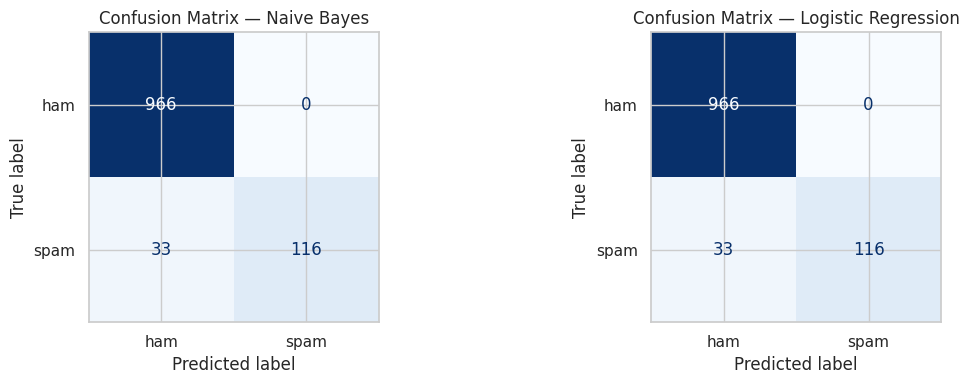

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name in zip(axes, [nb, lr], ['Naive Bayes', 'Logistic Regression']):
    y_pred = model.predict(X_test_tfidf)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.show()

## 6. Улучшение модели

Основная проблема — низкий Recall для спама (0.78): модель пропускает ~22% мошеннических сообщений.

Два способа улучшить:
1. Добавить признак длины сообщения — из EDA мы знаем, что спам заметно длиннее
2. Настроить порог классификации — по умолчанию 0.5, но для антифрода выгоднее снизить его, жертвуя Precision ради Recall

In [10]:
from scipy.sparse import hstack
from sklearn.preprocessing import MaxAbsScaler

# длина сообщения как дополнительный признак
train_lengths = df.loc[X_train.index, 'msg_length'].values.reshape(-1, 1)
test_lengths = df.loc[X_test.index, 'msg_length'].values.reshape(-1, 1)

scaler = MaxAbsScaler()
train_lengths_scaled = scaler.fit_transform(train_lengths)
test_lengths_scaled = scaler.transform(test_lengths)

# объединяем TF-IDF + длина
X_train_enhanced = hstack([X_train_tfidf, train_lengths_scaled])
X_test_enhanced = hstack([X_test_tfidf, test_lengths_scaled])

# обучаем улучшенную LR
lr_enhanced = LogisticRegression(max_iter=1000, random_state=42)
lr_enhanced.fit(X_train_enhanced, y_train)

# предсказания с порогом 0.3 вместо 0.5
y_proba = lr_enhanced.predict_proba(X_test_enhanced)[:, 1]
y_pred_tuned = (y_proba >= 0.3).astype(int)

print("Logistic Regression + длина сообщения + порог 0.3")
print("="*50)
print(classification_report(y_test, y_pred_tuned, target_names=['ham', 'spam']))

Logistic Regression + длина сообщения + порог 0.3
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.96      0.89      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



### 6.1 ROC-кривая

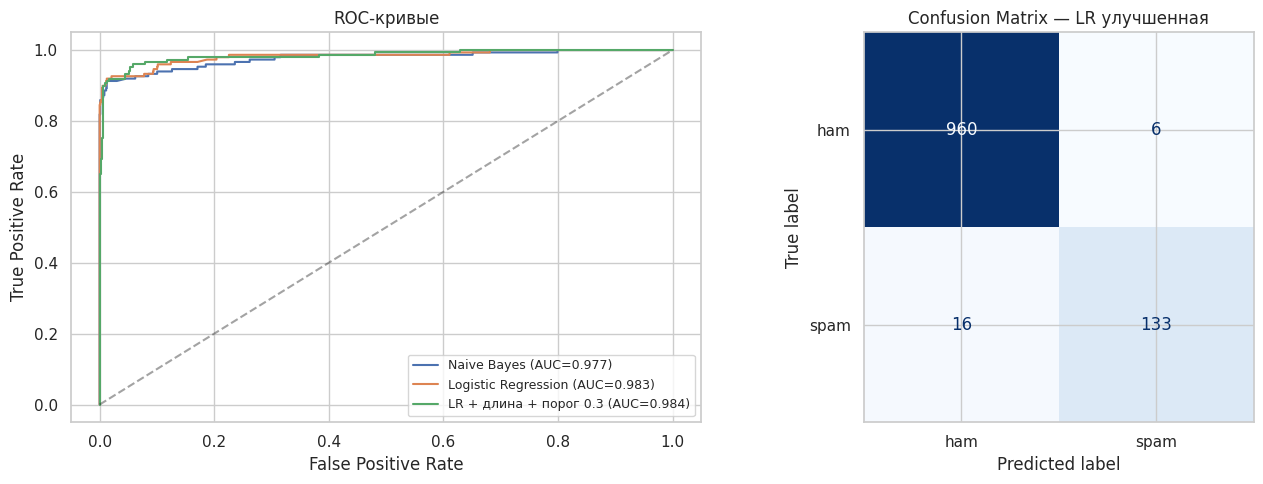

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривые всех моделей
models_roc = {
    'Naive Bayes': (nb, X_test_tfidf),
    'Logistic Regression': (lr, X_test_tfidf),
    'LR + длина + порог 0.3': (lr_enhanced, X_test_enhanced)
}

for name, (model, X) in models_roc.items():
    proba = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('ROC-кривые')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# Confusion matrix улучшенной модели
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — LR улучшенная')

plt.tight_layout()
plt.show()

## 7. Выводы

### Что сделано
- Проведён разведочный анализ 5 572 SMS-сообщений
- Построен пайплайн предобработки текста: нормализация, удаление стоп-слов, стемминг
- Обучены и сравнены две модели: Naive Bayes и Logistic Regression на TF-IDF признаках
- Улучшена итоговая модель за счёт добавления признака длины сообщения и настройки порога классификации

### Ключевые находки
- Спам-сообщения значительно длиннее обычных: медиана 149 vs 52 символа — сильный разделяющий признак
- Топ-маркеры спама: `free`, `£`, `call`, `txt` — типичный паттерн фишинговых сообщений
- Базовые модели дали одинаковый результат (F1=0.88), что говорит о высокой разделимости классов на TF-IDF
- Снижение порога с 0.5 до 0.3 подняло Recall с 0.78 до 0.89 при минимальной потере Precision

### Итоговые метрики лучшей модели (LR + длина + порог 0.3)

| Класс | Precision | Recall | F1 |
|-------|-----------|--------|----|
| ham   | 0.98      | 0.99   | 0.99 |
| spam  | 0.96      | 0.89   | 0.92 |


### Применимость к задачам антифрода
Подход напрямую переносится на задачи детекции фишинга и мошеннических коммуникаций:
классические NLP-признаки (TF-IDF + n-граммы) эффективно работают на коротких текстах,
а настройка порога позволяет гибко управлять балансом между Precision и Recall
в зависимости от бизнес-требований.